# RMS master — P1-angle scan - JUNE 18 RUN

> Note: in this run detector **H4 is off** (zero counts), so the live observables are
> $g^{(2)}_{33}$, $g^{(2)}_{55}$, $g^{(2)}_{35}$ and $R_{35}$. Anything involving H4 comes out `NaN`
> and is automatically skipped in the plots.

In [1]:
import os
import re
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

project_root = os.path.abspath('../../')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.hbt_core import HBTMeasurement
from src.hbt_visu import GridVisualizer

DATA_ROOT = Path(project_root) / "data/Jun18/RMS"
INTEGRATION_WINDOW_NS = 4.0
METHOD = "delay"
SHOW_GROUP_MATRICES = True
UNCERTAINTY_FROM_CHUNKS = False
SINGLES_KIND = "countrate"
DPI = 500


def parse_angle(folder_name):
    m = re.match(r'\s*(\d+(?:\.\d+)?)', folder_name)
    return float(m.group(1)) if m else np.nan

## 1. Discover the angle groups

Every sub-folder of `DATA_ROOT` that contains chunk `.pkl` files is treated as one P1 angle. The
chunks are sorted by their index and the corresponding `MERGED/` file (full integration) is picked
up when present. Empty folders (an angle queued but not yet acquired) are skipped, so re-running the
notebook after a new acquisition automatically includes it.

In [2]:
def _chunk_idx(p):
    m = re.search(r'chunk(\d+)', p.name)
    return int(m.group(1)) if m else -1


def discover_groups(root):
    """Return one dict per angle folder: name, parsed angle, chunk files and merged file."""
    groups = []
    for d in sorted(p for p in Path(root).iterdir() if p.is_dir() and p.name.upper() != "MERGED"):
        chunk_files = sorted(d.glob("*chunk*.pkl"), key=_chunk_idx)
        merged_files = sorted((d / "MERGED").glob("*MERGED*.pkl"))
        if not chunk_files and not merged_files:
            continue  # angle folder created but not acquired yet
        groups.append({
            "name": d.name,
            "angle": parse_angle(d.name),
            "dir": d,
            "chunk_files": chunk_files,
            "merged_file": merged_files[0] if merged_files else None,
        })
    groups.sort(key=lambda g: (np.isnan(g["angle"]), g["angle"]))
    return groups


groups = discover_groups(DATA_ROOT)
assert groups, f"No angle sub-folders with data found under {DATA_ROOT}"

print(f"Discovered {len(groups)} angle group(s) under {DATA_ROOT}:\n")
hdr = f"{'folder':14s}{'angle':>8s}{'chunks':>9s}{'merged':>9s}"
print(hdr)
print("-" * len(hdr))
for g in groups:
    print(f"{g['name']:14s}{g['angle']:8.0f}{len(g['chunk_files']):9d}"
          f"{('yes' if g['merged_file'] else 'no'):>9s}")

Discovered 9 angle group(s) under /Users/simon.wtmn/Desktop/Quantum_SHHG/data/Jun18/RMS:

folder           angle   chunks   merged
----------------------------------------
277-25             277        2      yes
282-22             282        2      yes
287-20             287        2      yes
297-14             297        2      yes
307-07             307        2      yes
317-359            317        2      yes
322-354            322        2      yes
327-350            327        2      yes
337-335            337        2      yes


## 2. Per-angle chunk analysis

For each angle group, the same stability read-out as the standalone RMS notebooks, looped over every
discovered angle:

* a summary table of the **direct** (artifact-free) $g^{(2)}(0)$ and $R$ per chunk (with mean / std),
* a bar comparison of $g^{(2)}$ and $R$ across chunks,
* the overlaid coherence / $g^{(2)}$ / $R$ sweep matrices (disable with `SHOW_GROUP_MATRICES = False`).

Columns / curves that involve a dead detector (here H4) are `NaN` and simply do not appear.

In [3]:
COLS = ["g2_33", "g2_44", "g2_55", "g2_34", "g2_35", "g2_45", "R_34", "R_35", "R_45"]
G2_TICK = [r"$g^{(2)}_{33}$", r"$g^{(2)}_{44}$", r"$g^{(2)}_{55}$",
           r"$g^{(2)}_{34}$", r"$g^{(2)}_{35}$", r"$g^{(2)}_{45}$"]
R_TICK = [r"$R_{34}$", r"$R_{35}$", r"$R_{45}$"]


def _auto(r, h, tau, method):
    a, b = r.get_ch(f"H{h}T"), r.get_ch(f"H{h}R")
    return r.compute_g2_delay(a, b, tau) if method == "delay" else r.compute_g2_direct(a, b)


def _cross(r, x, y, tau, method):
    a, b = r.get_ch(f"H{x}T"), r.get_ch(f"H{y}T")
    return r.compute_g2_delay(a, b, tau) if method == "delay" else r.compute_g2_direct(a, b)


def _R(r, x, y, tau, method):
    return r.compute_R_parameter(_cross(r, x, y, tau, method),
                                 _auto(r, x, tau, method), _auto(r, y, tau, method))


def measure(r, tau=INTEGRATION_WINDOW_NS, method="direct"):
    """The 9 standard quantities (3 auto + 3 cross g2, 3 R) for one measurement, as a dict."""
    vals = [_auto(r, 3, tau, method), _auto(r, 4, tau, method), _auto(r, 5, tau, method),
            _cross(r, 3, 4, tau, method), _cross(r, 3, 5, tau, method), _cross(r, 4, 5, tau, method),
            _R(r, 3, 4, tau, method), _R(r, 3, 5, tau, method), _R(r, 4, 5, tau, method)]
    return dict(zip(COLS, vals))


def load_group_runs(g):
    """HBTMeasurement list + labels for a group (chunks, or the merged file if no chunks)."""
    files = g["chunk_files"] if g["chunk_files"] else ([g["merged_file"]] if g["merged_file"] else [])
    runs = [HBTMeasurement(f) for f in files]
    labels = [(f"chunk {_chunk_idx(f)}" if "chunk" in f.name else "merged") for f in files]
    return runs, labels


def bar_compare(runs, labels, summary, ref):
    g2_cols = ["g2_33", "g2_44", "g2_55", "g2_34", "g2_35", "g2_45"]
    r_cols = ["R_34", "R_35", "R_45"]
    run_colors = GridVisualizer(runs, labels=labels, comparison_variable="Chunk").run_colors
    n = len(runs)
    fig, (axg, axr) = plt.subplots(1, 2, figsize=(16, 6), dpi=DPI,
                                   gridspec_kw={"width_ratios": [2, 1]})
    for ax, names, ticks in [(axg, g2_cols, G2_TICK), (axr, r_cols, R_TICK)]:
        x = np.arange(len(names))
        w = 0.8 / n
        for i, lab in enumerate(labels):
            y = [summary[lab][c] for c in names]
            ax.bar(x + (i - (n - 1) / 2) * w, y, width=w, color=run_colors[i],
                   label=lab, edgecolor="0.25", linewidth=0.5)
        ax.axhline(1.0, color="#313131", ls="--", lw=1.3, alpha=0.7)
        ax.set_xticks(x)
        ax.set_xticklabels(ticks)
        ax.grid(True, axis="y", alpha=0.25)
    axg.set_ylabel(r"$g^{(2)}(0)$ (direct)")
    axr.set_ylabel(r"$R$ parameter (direct)")
    axg.set_title(r"Auto / cross $g^{(2)}(0)$ per chunk")
    axr.set_title(r"Cauchy--Schwarz $R$ per chunk")
    axg.legend(loc="best", fontsize=10, ncol=max(1, n // 3))
    fig.suptitle(rf"{ref.material}  ($P = {ref.power_mw:g}$ mW)", fontsize=14, y=1.0)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()


def analyze_group(g, show_matrices=True):
    runs, labels = load_group_runs(g)
    ref = runs[0]
    print("=" * 96)
    print(f"ANGLE {g['name']}   (P1 = {g['angle']:g})   —   {len(runs)} chunk(s)")
    print(f"  {ref.acquisition_summary()}")
    print(f"  {ref.acquisition_details()}")

    hdr = f"{'chunk':12s}" + "".join(f"{c:>9s}" for c in COLS)
    print(hdr)
    print("-" * len(hdr))
    summary = {}
    for r, lab in zip(runs, labels):
        d = measure(r, method="direct")
        summary[lab] = d
        print(f"{lab:12s}" + "".join(f"{d[c]:9.3f}" for c in COLS))
    if len(runs) > 1:
        arr = np.array([[summary[l][c] for c in COLS] for l in labels], float)
        print("-" * len(hdr))
        print(f"{'mean':12s}" + "".join(f"{v:9.3f}" for v in np.nanmean(arr, axis=0)))
        print(f"{'std':12s}" + "".join(f"{v:9.3f}" for v in np.nanstd(arr, axis=0)))

    bar_compare(runs, labels, summary, ref)

    if show_matrices:
        comp = GridVisualizer(runs, labels=labels, comparison_variable="Chunk (time segment)")
        comp.plot_coherence(integration_window_ns=2)
        comp.plot_g2(methods=["delay"], tau_min=0.3, tau_max=25, step=1.0, ylim=(1, 3))
        comp.plot_R(methods=["delay"], tau_min=0.3, tau_max=20, step=1.0)

    return summary

In [4]:
# group_summaries = {}
# for g in groups:
#     group_summaries[g["name"]] = analyze_group(g, show_matrices=SHOW_GROUP_MATRICES)

## 3. $g^{(2)}(0)$ and $R$ vs P1 angle

The headline plot: every angle on one figure. For each angle the representative value is taken from
the **merged** file (full integration; falls back to the first chunk if no merged file exists), at a
fixed integration window $\tau_{in} = $ `INTEGRATION_WINDOW_NS` with the chosen `METHOD`. The error
bars show the chunk-to-chunk spread (std across the time segments) as a stability indicator.

Left: the auto / cross $g^{(2)}(0)$ vs angle. Right: the Cauchy–Schwarz $R$ vs angle. Series that are
all-`NaN` (dead-detector pairs) are omitted automatically.

In [5]:
# Harmonic pairs, polarisation combos and the full key set used for the vs-angle scan.
HARMS = ["3", "4", "5"]
PAIRS = [("3", "4"), ("3", "5"), ("4", "5")]
COMBOS = ["TT", "TR", "RT", "RR"]   # which arm of (harmonic A, harmonic B) is correlated

AUTO_KEYS = [f"g2_{h}{h}" for h in HARMS]
G2_COMBO_KEYS = [f"g2_{a}{b}_{c}" for a, b in PAIRS for c in COMBOS]
R_COMBO_KEYS = [f"R_{a}{b}_{c}" for a, b in PAIRS for c in COMBOS]
ALL_KEYS = AUTO_KEYS + G2_COMBO_KEYS + R_COMBO_KEYS


def _g2_auto(r, h, tau, method):
    a, b = r.get_ch(f"H{h}R"), r.get_ch(f"H{h}T")
    return r.compute_g2_delay(a, b, tau) if method == "delay" else r.compute_g2_direct(a, b)


def _g2_combo(r, hA, hB, combo, tau, method):
    a, b = r.get_ch(f"H{hA}{combo[0]}"), r.get_ch(f"H{hB}{combo[1]}")
    return r.compute_g2_delay(a, b, tau) if method == "delay" else r.compute_g2_direct(a, b)


def measure_combos(r, tau=INTEGRATION_WINDOW_NS, method=METHOD):
    """Auto g2 (per harmonic) + cross g2 and R for every TT/TR/RT/RR combo, as a flat dict."""
    out = {f"g2_{h}{h}": _g2_auto(r, h, tau, method) for h in HARMS}
    for hA, hB in PAIRS:
        aA, aB = _g2_auto(r, hA, tau, method), _g2_auto(r, hB, tau, method)
        for combo in COMBOS:
            cross = _g2_combo(r, hA, hB, combo, tau, method)
            out[f"g2_{hA}{hB}_{combo}"] = cross
            out[f"R_{hA}{hB}_{combo}"] = r.compute_R_parameter(cross, aA, aB)
    return out


def measure_singles(r, kind=SINGLES_KIND):
    """Single counts (or count rate) for every physical detector, keyed by channel number."""
    return {ch: r.channel_intensity(ch, kind=kind) for ch in r.channel_map}


def representative_run(g):
    """Best single measurement for an angle: the merged file, else the first chunk."""
    if g["merged_file"] is not None:
        return HBTMeasurement(g["merged_file"])
    if g["chunk_files"]:
        return HBTMeasurement(g["chunk_files"][0])
    return None


def collect_vs_angle(groups, tau=INTEGRATION_WINDOW_NS, method=METHOD,
                     uncertainty_from_chunks=UNCERTAINTY_FROM_CHUNKS,
                     singles_kind=SINGLES_KIND):
    """Per-angle g2 / R for every combo and per-channel singles, taken from the merged file.

    uncertainty_from_chunks:
        True  -> also load each chunk and report the std across them as an error bar (slower),
        False -> merged file only, no error bars (faster, the efficient default).
    """
    angles, names = [], []
    value = {k: [] for k in ALL_KEYS}
    err = {k: [] for k in ALL_KEYS}
    channels = None
    s_value, s_err = {}, {}
    for g in groups:
        rep = representative_run(g)
        if rep is None:
            continue
        if channels is None:  # (channel number, physical name), e.g. (1, 'H3T')
            channels = sorted(rep.channel_map.items())
            s_value = {ch: [] for ch, _ in channels}
            s_err = {ch: [] for ch, _ in channels}
        angles.append(g["angle"])
        names.append(g["name"])
        d = measure_combos(rep, tau=tau, method=method)
        s = measure_singles(rep, kind=singles_kind)
        cd = sd = None
        if uncertainty_from_chunks and len(g["chunk_files"]) > 1:
            runs_c = [HBTMeasurement(f) for f in g["chunk_files"]]
            cd = [measure_combos(r, tau=tau, method=method) for r in runs_c]
            sd = [measure_singles(r, kind=singles_kind) for r in runs_c]
        for k in ALL_KEYS:
            value[k].append(d[k])
            err[k].append(np.nanstd([x[k] for x in cd]) if cd else 0.0)
        for ch, _ in channels:
            s_value[ch].append(s[ch])
            s_err[ch].append(np.nanstd([x[ch] for x in sd]) if sd else 0.0)
    order = np.argsort(np.array(angles, float))
    out = {"angle": np.array(angles, float)[order],
           "names": [names[i] for i in order],
           "has_err": bool(uncertainty_from_chunks),
           "channels": channels,
           "singles_kind": singles_kind}
    for k in ALL_KEYS:
        out[k] = np.array(value[k], float)[order]
        out[k + "_err"] = np.array(err[k], float)[order]
    for ch, _ in channels:
        out[f"singles_{ch}"] = np.array(s_value[ch], float)[order]
        out[f"singles_{ch}_err"] = np.array(s_err[ch], float)[order]
    return out


scan = collect_vs_angle(groups, tau=INTEGRATION_WINDOW_NS, method=METHOD,
                        uncertainty_from_chunks=UNCERTAINTY_FROM_CHUNKS,
                        singles_kind=SINGLES_KIND)

# Text summary: only the keys that carry data (drop all-NaN dead-detector combos).
live_keys = [k for k in ALL_KEYS if np.any(np.isfinite(scan[k]))]
hdr = f"{'angle':>8s}" + "".join(f"{k:>12s}" for k in live_keys)
print(f"g2 / R vs P1 angle  (tau_in = {INTEGRATION_WINDOW_NS:g} ns, method = {METHOD}, "
      f"uncertainty_from_chunks = {scan['has_err']})\n")
print(hdr)
print("-" * len(hdr))
for i, a in enumerate(scan["angle"]):
    print(f"{a:8.0f}" + "".join(f"{scan[k][i]:12.3f}" for k in live_keys))

g2 / R vs P1 angle  (tau_in = 4 ns, method = delay, uncertainty_from_chunks = False)

   angle       g2_33       g2_55    g2_35_TT    g2_35_TR    g2_35_RT    g2_35_RR     R_35_TT     R_35_TR     R_35_RT     R_35_RR
--------------------------------------------------------------------------------------------------------------------------------
     277       1.149       1.287       1.216       1.216       1.203       1.195       1.001       1.001       0.979       0.966
     282       1.145       1.284       1.204       1.208       1.190       1.187       0.986       0.993       0.963       0.959
     287       1.156       1.299       1.224       1.220       1.214       1.207       0.998       0.991       0.981       0.970
     297       1.194       1.368       1.277       1.268       1.258       1.259       0.998       0.984       0.969       0.970
     307       1.273       1.490       1.356       1.359       1.350       1.348       0.969       0.974       0.962       0.958
     317   

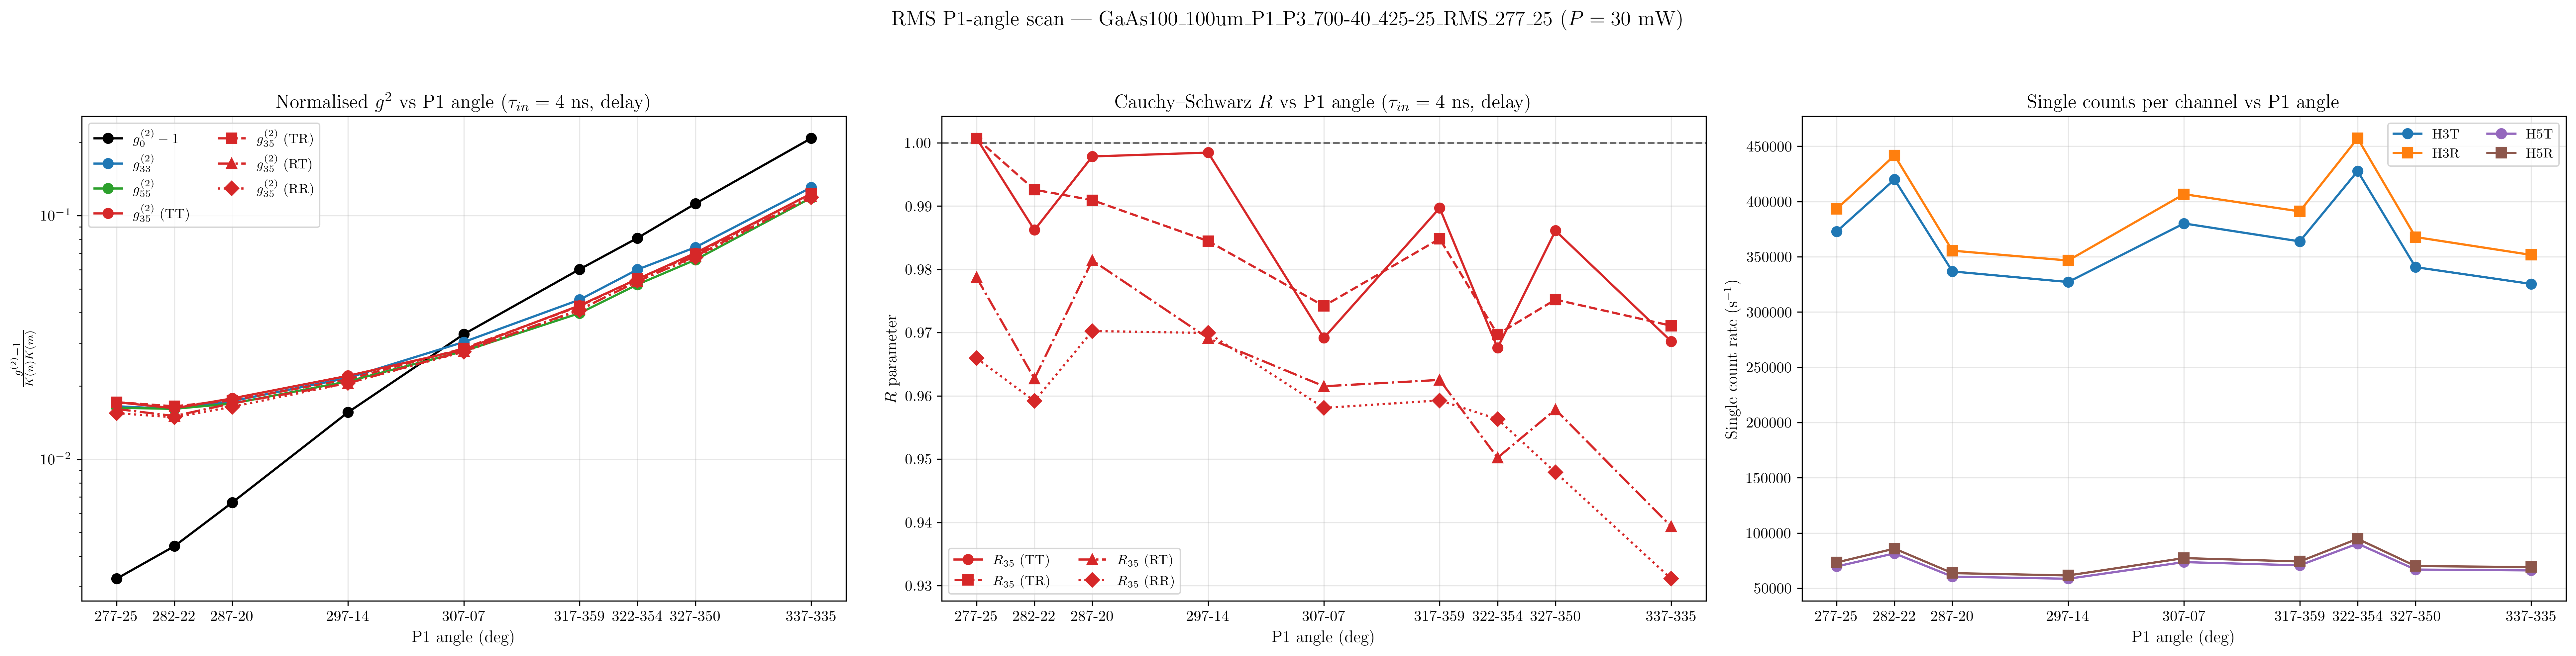

In [9]:
# colour = harmonic pair, line style / marker = polarisation combo.
angle_deg = np.array([277, 282, 287, 297, 307, 317, 322, 327, 337])
g2_minus_1 = np.array([0.00323185, 0.00439639, 0.00664425, 0.01558493, 0.03260049, 0.06022065, 0.08092856, 0.11191452, 0.20761988])


AUTO_COLOR = {"3": "#1f77b4", "4": "#9467bd", "5": "#2ca02c"}
PAIR_COLOR = {("3", "4"): "#ff7f0e", ("3", "5"): "#d62728", ("4", "5"): "#8c564b"}
COMBO_STYLE = {"TT": ("-", "o"), "TR": ("--", "s"), "RT": ("-.", "^"), "RR": (":", "D")}

ref = representative_run(groups[0])
angle = scan["angle"]
yerr_of = (lambda k: scan[k + "_err"]) if scan["has_err"] else (lambda k: None)


def _plot(ax, key, color, style, label, scale=1.0, excess=False):
    y = scan[key]
    if np.all(np.isnan(y)):
        return
    e = yerr_of(key)
    if excess:                       # plot (g2 - 1) / (n_a * n_b)
        y = (y - 1.0) / scale
        if e is not None:
            e = e / scale
    ls, mk = style
    ax.errorbar(angle, y, yerr=e, color=color, ls=ls, marker=mk, ms=7,
                lw=1.6, capsize=3, label=label)


fig, (axg, axr, axs) = plt.subplots(1, 3, figsize=(26, 6.5), dpi=300)

# normalised excess: (g2 - 1) / (n_a * n_b)  -> 3**2 for 33, 5**2 for 55, 3*5 for 35
for h in HARMS:
    if h == "5":
        _plot(axg, f"g2_{h}{h}", AUTO_COLOR[h], ("-", "o"), rf"$g^{{(2)}}_{{{h}{h}}}$",
          scale=4.2**2, excess=True)
    else:
        _plot(axg, f"g2_{h}{h}", AUTO_COLOR[h], ("-", "o"), rf"$g^{{(2)}}_{{{h}{h}}}$",
          scale=3**2, excess=True)
for hA_orig, hB_orig in PAIRS:
    # We need to preserve the original (hA, hB) keys for color lookup etc.
    hA = 4.2 if hA_orig == "5" else 3 if hA_orig == "3" else hA_orig
    hB = 4.2 if hB_orig == "5" else 3 if hB_orig == "3" else hB_orig
    # Create scaling factor using numeric value, but use original string for keys/labels.
    for combo in COMBOS:
        scale = float(hA) * float(hB)
        _plot(axg, f"g2_{hA_orig}{hB_orig}_{combo}", PAIR_COLOR[(hA_orig, hB_orig)], COMBO_STYLE[combo],
              rf"$g^{{(2)}}_{{{hA_orig}{hB_orig}}}$ ({combo})", scale=scale, excess=True)
       
axg.plot(angle_deg, g2_minus_1, color="black", ls="-", marker="o", ms=7, lw=1.6, label="$g^{(2)}_0-1$")
# axg.axhline(0, color="#313131", ls="--", lw=1.3, alpha=0.7)
axg.set_xlabel(r"P1 angle (deg)")
axg.set_yscale("log")
axg.set_ylabel(r"$\frac{g^{(2)}-1}{K(n)K(m)}$")
axg.set_title(rf"Normalised $g^{(2)}$ vs P1 angle  ($\tau_{{in}} = {INTEGRATION_WINDOW_NS:g}$ ns, {METHOD})")
axg.grid(True, alpha=0.3)
axg.legend(loc="best", fontsize=10, ncol=2)

# R: the four combos per pair
for hA, hB in PAIRS:
    for combo in COMBOS:
        _plot(axr, f"R_{hA}{hB}_{combo}", PAIR_COLOR[(hA, hB)], COMBO_STYLE[combo],
              rf"$R_{{{hA}{hB}}}$ ({combo})")
axr.axhline(1.0, color="#313131", ls="--", lw=1.3, alpha=0.7)
axr.set_xlabel(r"P1 angle (deg)")
axr.set_ylabel(r"$R$ parameter")
axr.set_title(rf"Cauchy--Schwarz $R$ vs P1 angle  ($\tau_{{in}} = {INTEGRATION_WINDOW_NS:g}$ ns, {METHOD})")
axr.grid(True, alpha=0.3)
axr.legend(loc="best", fontsize=10, ncol=2)

# singles: physical single-count(rate) per detector vs angle (dead channels auto-skipped)
singles_ylabel = (r"Single count rate (s$^{-1}$)" if scan["singles_kind"] == "countrate"
                  else r"Single counts")
for idx, (ch, name) in enumerate(scan["channels"]):
    y = scan[f"singles_{ch}"]
    if not np.any(np.isfinite(y)) or np.nanmax(y) <= 0:
        continue
    mk = "o" if name.endswith("T") else "s"
    axs.errorbar(angle, y, yerr=(scan[f"singles_{ch}_err"] if scan["has_err"] else None),
                 color=plt.cm.tab10(idx % 10), marker=mk, ms=7, lw=1.6, capsize=3, label=name)
axs.set_xlabel(r"P1 angle (deg)")
axs.set_ylabel(singles_ylabel)
axs.set_title(r"Single counts per channel vs P1 angle")
axs.grid(True, alpha=0.3)
axs.legend(loc="best", fontsize=10, ncol=2)

for ax in (axg, axr, axs):
    ax.set_xticks(angle)
    ax.set_xticklabels([n for n in scan["names"]], rotation=0)

fig.suptitle(rf"RMS P1-angle scan — {ref.material}  ($P = {ref.power_mw:g}$ mW)",
             fontsize=15, y=1.01)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()